In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv('../data/Wholesale customers data.csv')

In [3]:
data.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
data.shape

(440, 8)

In [5]:
data.dtypes

Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

In [6]:
data.isna().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [8]:
data.columns=data.columns.str.lower().str.strip()

<h2>Co-relative Analysis🧩</h2>

In [9]:
data['region'].value_counts()

region
3    316
1     77
2     47
Name: count, dtype: int64

In [10]:
numerical_features=data.drop(columns=['channel','region'])

In [11]:
numerical_features.describe()

,fresh,milk,grocery,frozen,detergents_paper,delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


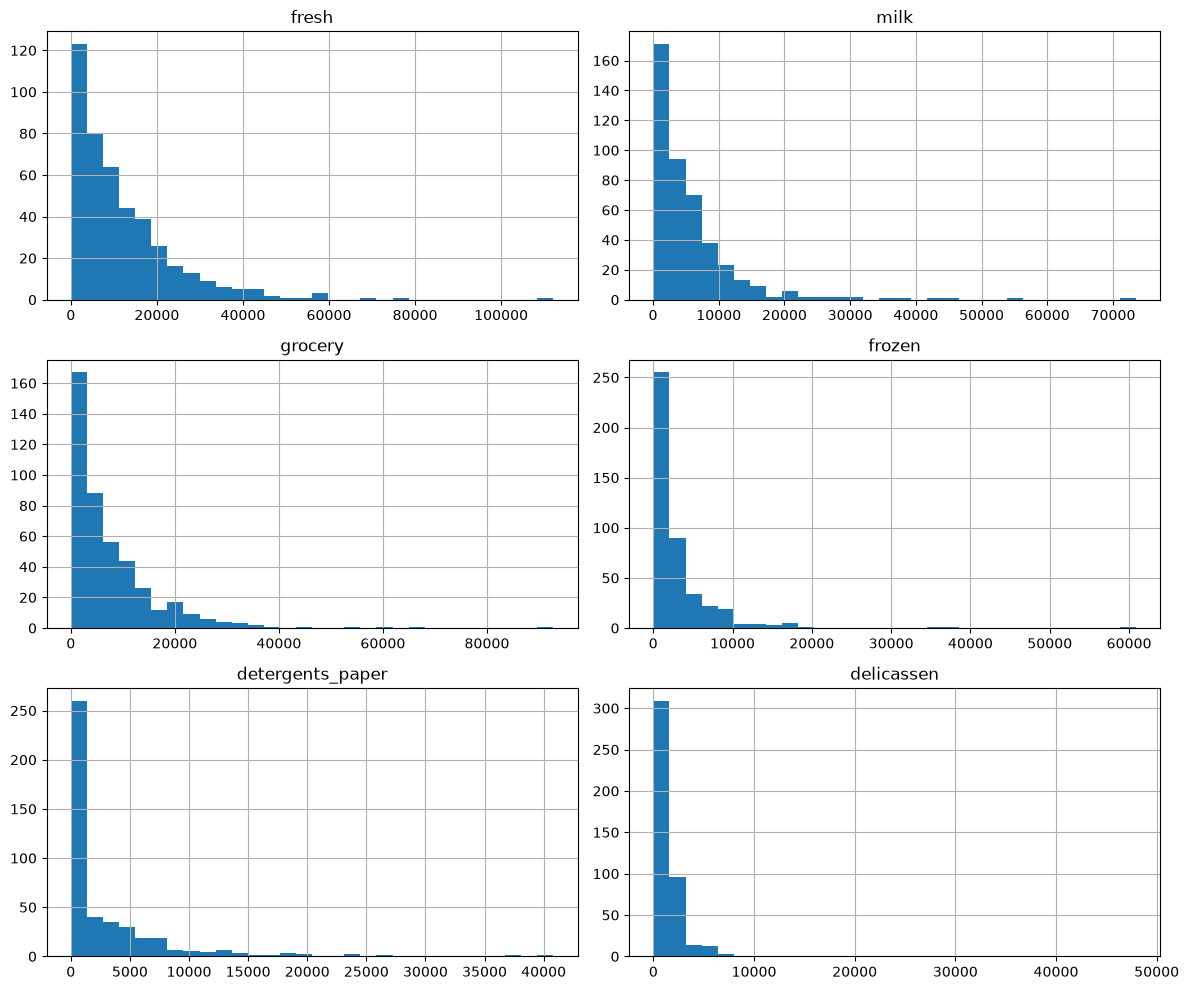

fresh                2.561323
grocery              3.587429
detergents_paper     3.631851
milk                 4.053755
frozen               5.907986
delicassen          11.151586
dtype: float64

In [12]:
numerical_features.hist(figsize=(12, 10), bins=30)
plt.tight_layout()
plt.show()
numerical_features.skew(numeric_only=True).sort_values()

In [13]:
numerical_f=numerical_features.columns

In [14]:
numerical_bounds={}
for feature in numerical_f:
    feature_describe=data[feature].describe()
    Q1=feature_describe.values[4]
    Q3=feature_describe.values[6]
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    numerical_bounds[feature]=[lower,upper]

In [15]:
numerical_bounds

{'fresh': [np.float64(-17581.25), np.float64(37642.75)],
 'milk': [np.float64(-6952.875), np.float64(15676.125)],
 'grocery': [np.float64(-10601.125), np.float64(23409.875)],
 'frozen': [np.float64(-3475.75), np.float64(7772.25)],
 'detergents_paper': [np.float64(-5241.125), np.float64(9419.875)],
 'delicassen': [np.float64(-1709.75), np.float64(3938.25)]}

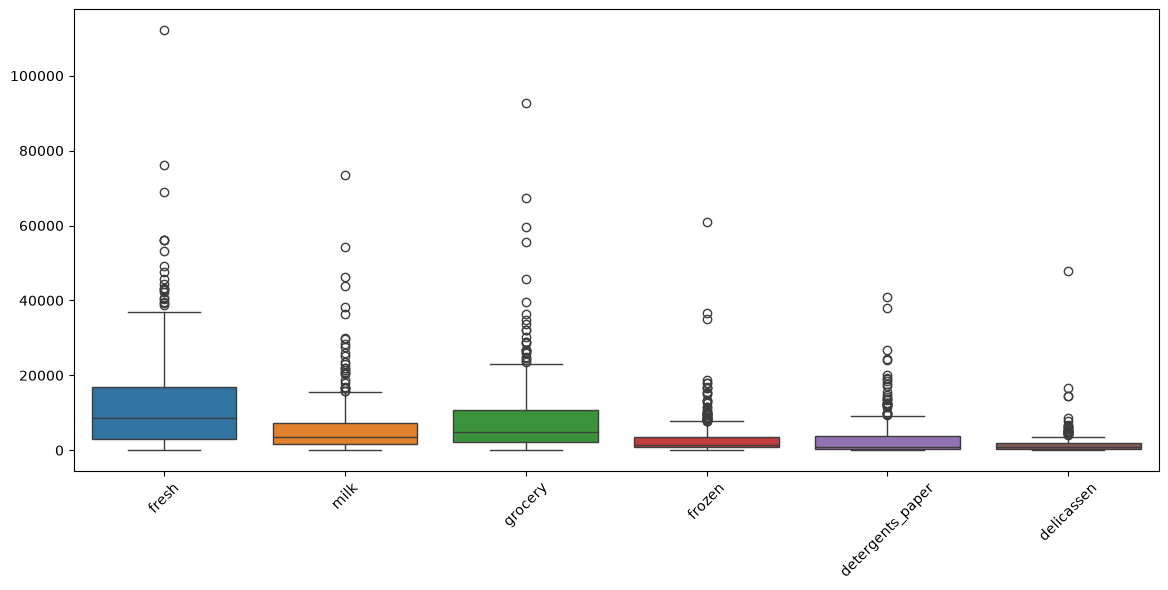

In [16]:
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.boxplot(data=numerical_features.select_dtypes("number"))
plt.xticks(rotation=45)
plt.show()

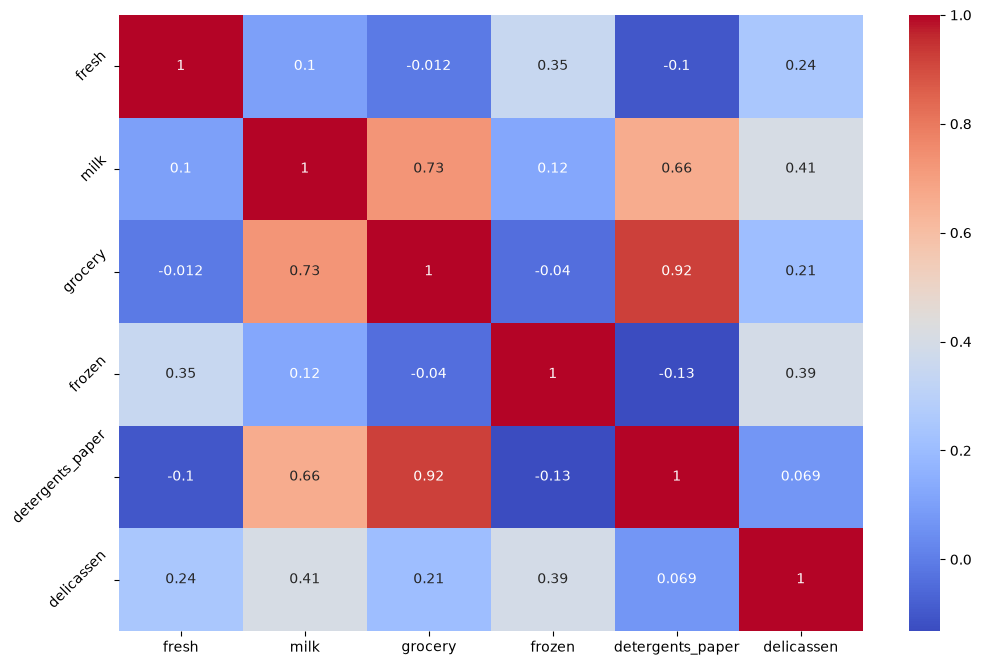

In [17]:
corr = numerical_features.select_dtypes("number").corr()

plt.figure(figsize=(12, 8))

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.yticks(rotation=45)
plt.show()

In [18]:
outlier_count={}
for feature in numerical_f:
    upper= numerical_bounds[feature][1]
    count=(data[feature]>upper).sum()
    outlier_count[feature]=count

In [19]:
outlier_count

{'fresh': np.int64(20),
 'milk': np.int64(28),
 'grocery': np.int64(24),
 'frozen': np.int64(43),
 'detergents_paper': np.int64(30),
 'delicassen': np.int64(27)}

<h3>feature Engineering</h3>

In [20]:
numerical_features_log=np.log1p(numerical_features)

In [21]:
numerical_features_log

,fresh,milk,grocery,frozen,detergents_paper,delicassen
0,9.446992,9.175438,8.930891,5.370638,7.891705,7.199678
1,8.861917,9.191259,9.166284,7.474772,8.099858,7.482682
2,8.756840,9.083529,8.947026,7.785721,8.165364,8.967632
3,9.492960,7.087574,8.348064,8.764834,6.230481,7.489412
4,10.026413,8.596189,8.881697,8.272826,7.483244,8.553718
...,...,...,...,...,...,...
435,10.299037,9.396986,9.682092,9.483112,5.209486,7.698483
436,10.577172,7.266827,6.639876,8.414274,4.543295,7.760893
437,9.584108,9.647885,10.317053,6.082219,9.605216,7.532624
438,9.239025,7.591862,7.711101,6.946014,5.129899,7.661998


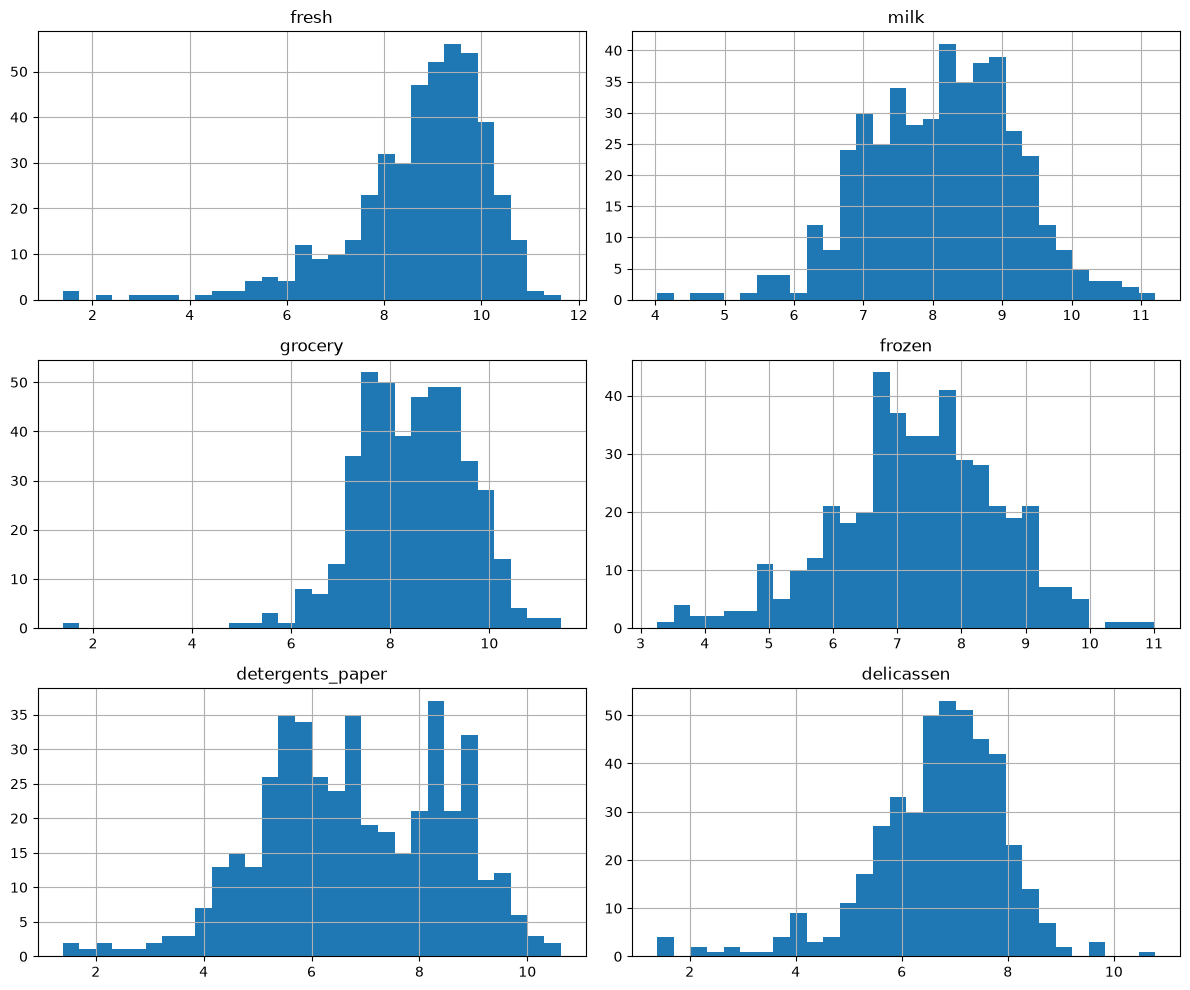

fresh              -1.575326
delicassen         -1.091827
grocery            -0.674938
frozen             -0.352655
detergents_paper   -0.235961
milk               -0.224063
dtype: float64

In [22]:
numerical_features_log.hist(figsize=(12, 10), bins=30)
plt.tight_layout()
plt.show()
numerical_features_log.skew(numeric_only=True).sort_values()

In [23]:
from sklearn.preprocessing import StandardScaler
Scaler=StandardScaler()
numerical_scaled=Scaler.fit_transform(numerical_features_log)

In [24]:
numerical_scaled=pd.DataFrame(
    numerical_scaled,
    columns=numerical_features_log.columns,
    index=numerical_features_log.index
)

In [25]:
numerical_scaled.head()

,fresh,milk,grocery,frozen,detergents_paper,delicassen
0,0.486184,0.976299,0.440155,-1.509250,0.644143,0.408966
1,0.087889,0.990956,0.652171,0.134052,0.766043,0.627926
2,0.016356,0.891151,0.454687,0.376899,0.804405,1.776833
3,0.517477,-0.957973,-0.084792,1.141574,-0.328712,0.633133
4,0.880631,0.439662,0.395847,0.757322,0.404939,1.456588


In [26]:
numerical_scaled.describe()

,fresh,milk,grocery,frozen,detergents_paper,delicassen
count,4.400000e+02,4.400000e+02,4.400000e+02,4.400000e+02,4.400000e+02,4.400000e+02
mean,3.229740e-17,-7.105427e-16,-1.081963e-15,2.987509e-16,-6.297992e-16,-2.220446e-17
std,1.001138e+00,1.001138e+00,1.001138e+00,1.001138e+00,1.001138e+00,1.001138e+00
min,-5.001217e+00,-3.794924e+00,-6.355190e+00,-3.159118e+00,-3.165591e+00,-4.088856e+00
25%,-4.659360e-01,-7.281616e-01,-6.909415e-01,-5.405240e-01,-7.260542e-01,-5.081462e-01
50%,2.148413e-01,6.931547e-02,2.257341e-02,2.180154e-02,-5.009412e-02,1.567407e-01
75%,6.836939e-01,7.031679e-01,7.491423e-01,6.818408e-01,8.683740e-01,6.469559e-01
max,1.970662e+00,2.856582e+00,2.698281e+00,2.900093e+00,2.240218e+00,3.177354e+00


<h2>Modelling 🤖</h2>

In [27]:
from sklearn.cluster import KMeans
inertia=[]

for i in range(2,11):
    kmeans=KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(numerical_scaled)
    inertia.append(kmeans.inertia_)

<p><bold>Using Elbow Method to find Best K value</bold></p>

Text(0, 0.5, 'Inertia')

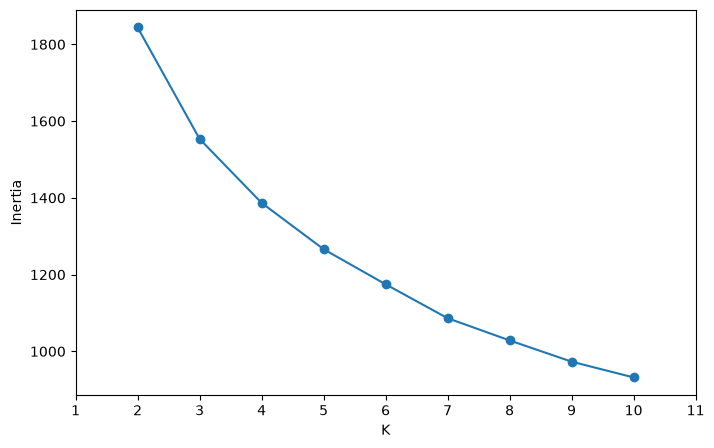

In [28]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11),inertia,marker='o')
plt.xlabel('K')
plt.xticks(range(1,12,1))

plt.ylabel('Inertia')



<p><bold>Using Silhoutte Method to find Best K value</bold></p>

In [29]:
from sklearn.metrics import silhouette_score
scores=[]
for i in range(2,11):
    kmeans=KMeans(n_clusters=i,random_state=42,n_init=10)

    labels=kmeans.fit_predict(numerical_scaled)
    score=silhouette_score(numerical_scaled,labels)
    scores.append(score)

In [30]:
scores

[0.2903284869973543,
 0.25941565559741453,
 0.1884954525130424,
 0.1915850843191521,
 0.20088699307469401,
 0.19577973280303204,
 0.18517472607336677,
 0.19650108536770935,
 0.1905229602145307]

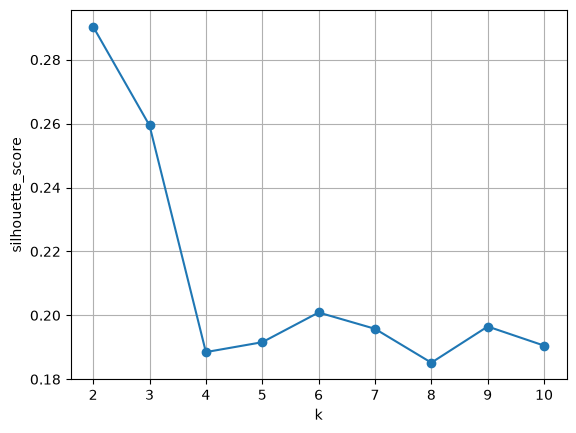

In [31]:
plt.plot(range(2,11),scores,marker='o')
plt.xlabel('k')
plt.xticks(range(2,11))
plt.ylabel('silhouette_score')
plt.grid()

In [32]:
kmeans_3=KMeans(n_clusters=3,random_state=42,n_init=10)
labels_3=kmeans_3.fit_predict(numerical_scaled)

kmeans_2=KMeans(n_clusters=2,random_state=42,n_init=10)
labels_2=kmeans_2.fit_predict(numerical_scaled)

In [33]:
pd.Series(labels_3).value_counts()

2    213
1    147
0     80
Name: count, dtype: int64

In [34]:
pd.Series(labels_2).value_counts()

0    252
1    188
Name: count, dtype: int64

In [35]:
clusteer_3=numerical_features.copy()

In [36]:
clusteer_3['labels']=labels_3

In [37]:
cluster_2=numerical_features.copy()
cluster_2['labels']=labels_2

In [38]:
clusteer_3.groupby('labels').mean()

,fresh,milk,grocery,frozen,detergents_paper,delicassen
labels,,,,,,
0,2898.575000,7135.937500,12569.712500,606.550000,5554.387500,782.862500
1,17042.836735,10559.666667,13333.598639,4133.095238,4987.020408,2846.591837
2,11938.723005,2005.685446,2502.093897,3265.544601,424.478873,891.384977


In [39]:
cluster_2.groupby('labels').mean()

,fresh,milk,grocery,frozen,detergents_paper,delicassen
labels,,,,,,
0,13973.126984,2401.750000,2918.706349,3705.670635,491.944444,1038.043651
1,9355.867021,10346.361702,14697.063830,2222.452128,6084.505319,2177.425532


In [40]:
cluster_means = clusteer_3.groupby("labels").mean()

cluster_means_scaled = StandardScaler().fit_transform(cluster_means)

cluster_means_scaled = pd.DataFrame(
    cluster_means_scaled,
    index=cluster_means.index,
    columns=cluster_means.columns
)

In [41]:
cluster_means_scaled

,fresh,milk,grocery,frozen,detergents_paper,delicassen
labels,,,,,,
0,-1.321405,0.161822,0.628312,-1.374245,0.827043,-0.763554
1,1.097069,1.135790,0.783076,0.976239,0.579958,1.412669
2,0.224336,-1.297611,-1.411388,0.398006,-1.407000,-0.649116


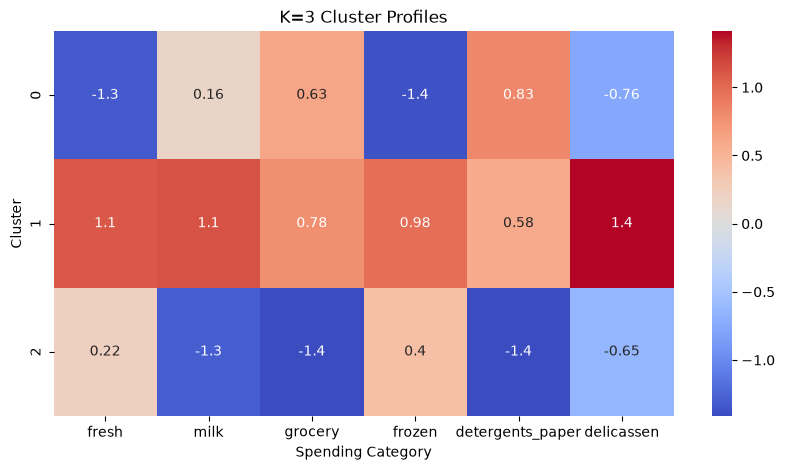

In [42]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    cluster_means_scaled,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("K=3 Cluster Profiles")
plt.xlabel("Spending Category")
plt.ylabel("Cluster")
plt.show()

In [43]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(numerical_scaled)

print("Explained variance:", pca.explained_variance_ratio_)
print("Total variance retained:", pca.explained_variance_ratio_.sum())

Explained variance: [0.44077752 0.27194917]
Total variance retained: 0.7127266893428759


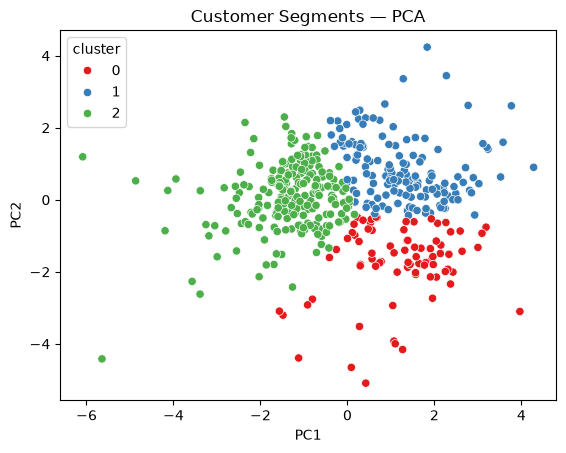

In [44]:
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster"] = labels_3

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set1"
)

plt.title("Customer Segments — PCA")
plt.show()

In [46]:
clusteer_3.groupby("labels").median()

,fresh,milk,grocery,frozen,detergents_paper,delicassen
labels,,,,,,
0,1492.5,6300.5,10502.5,376.0,4217.5,434.5
1,12126.0,7184.0,9965.0,2005.0,3378.0,2005.0
2,9612.0,1601.0,2155.0,2121.0,274.0,686.0


In [47]:
from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(numerical_scaled, labels_3)
print(db_score)

1.3405631342807725


<h2>Agglomerative Hierarchical Clustering</h2>

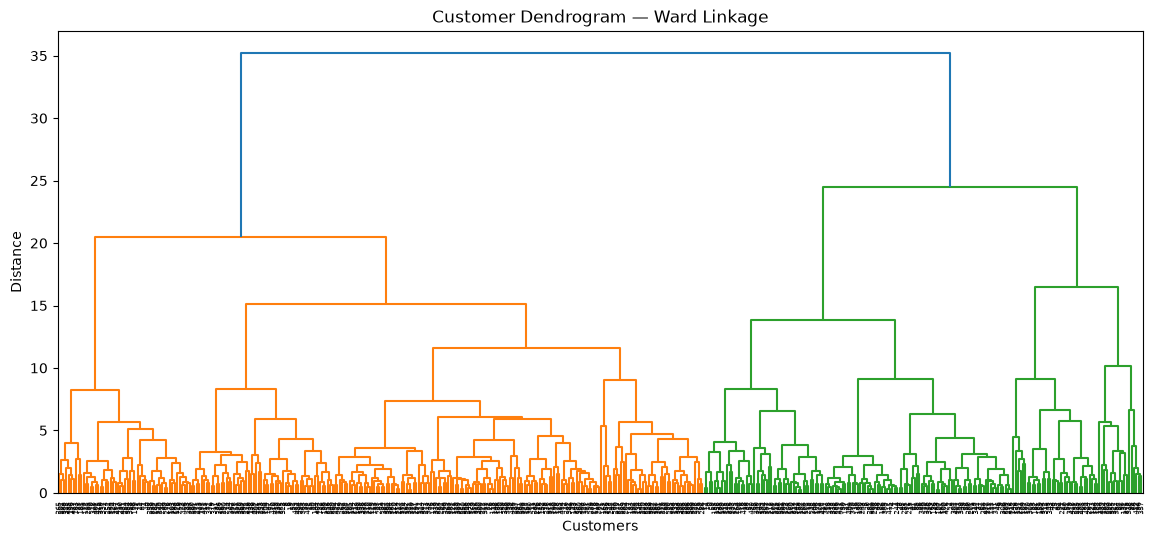

In [49]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

sch.dendrogram(
    sch.linkage(numerical_scaled, method="ward")
)

plt.title("Customer Dendrogram — Ward Linkage")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [50]:
from sklearn.cluster import AgglomerativeClustering
agglomerative = AgglomerativeClustering(n_clusters=3, linkage="ward")
agglomerative_labels = agglomerative.fit_predict(numerical_scaled)

In [53]:
clusteer_3["agglomerative_labels"] = agglomerative_labels

In [54]:
clusteer_3

,fresh,milk,grocery,frozen,detergents_paper,delicassen,labels,agglomerative_labels
0,12669,9656,7561,214,2674,1338,1,2
1,7057,9810,9568,1762,3293,1776,1,2
2,6353,8808,7684,2405,3516,7844,1,2
3,13265,1196,4221,6404,507,1788,2,0
4,22615,5410,7198,3915,1777,5185,1,0
...,...,...,...,...,...,...,...,...
435,29703,12051,16027,13135,182,2204,1,0
436,39228,1431,764,4510,93,2346,2,0
437,14531,15488,30243,437,14841,1867,1,2
438,10290,1981,2232,1038,168,2125,2,0


In [56]:
pd.Series(agglomerative_labels).value_counts()

0    262
2    125
1     53
Name: count, dtype: int64

In [57]:
agglo_silhoute=silhouette_score(numerical_scaled, agglomerative_labels)

In [58]:
agglo_silhoute

0.2546567404941345